# Feature engineering: do physics ratios, rolling stats or healthy-engine
# residuals help a model generalise to an unseen load?

Six feature sets (raw, +physics, +physics+rolling, and the same three with
healthy-engine residuals in place of the raw day-marker channels) scored
with logistic regression and LightGBM under the same leave-one-load-out
(LOLO) protocol as notebook 02. Physics and rolling columns are computed
once, before the LOLO loop, from `keyframe.features.build_feature_table`;
residuals are fitted inside each fold, on that fold's healthy rows only.

**Main findings:** read from the table below once computed.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from keyframe import evaluate, experiments, features, paths

paths.FIGURES.mkdir(parents=True, exist_ok=True)
paths.RESULTS.mkdir(parents=True, exist_ok=True)

## Pooled and per-fold scores for every feature set x model combination

Predictions come from the cached experiment outputs
(`uv run python -m keyframe.experiments ablation ...`), not recomputed here.

In [2]:
MODELS = ["logreg", "lightgbm"]

summaries = []
for feature_set in features.FEATURE_SETS:
    for model in MODELS:
        predictions = experiments.load_ablation(feature_set, model)
        if predictions is None:
            continue
        summary = evaluate.summarise(predictions)
        summary.insert(0, "feature_set", feature_set)
        summary.insert(1, "model", model)
        summaries.append(summary)
results = pd.concat(summaries, ignore_index=True)
evaluate.log_results("03_ablation", results)
results

,feature_set,model,fold,macro_f1,accuracy,false_alarm_rate,worst_recall,worst_recall_class
0,raw,logreg,pooled,0.439858,0.522500,0.225194,0.127199,TD
1,raw,logreg,40,0.300006,0.636398,0.000125,0.000000,AF
2,raw,logreg,60,0.435900,0.406866,0.536238,0.018141,CW
3,raw,logreg,75,0.550197,0.527237,0.397379,0.000000,AC
4,raw,logreg,85,0.361232,0.545892,0.000696,0.000000,AC
5,raw,lightgbm,pooled,0.389392,0.531622,0.321084,0.002549,TD
6,raw,lightgbm,40,0.350787,0.485801,0.440435,0.000000,AC
7,raw,lightgbm,60,0.354198,0.568959,0.147548,0.000000,AC
8,raw,lightgbm,75,0.436228,0.466204,0.213124,0.000000,AF
9,raw,lightgbm,85,0.482006,0.571876,0.465478,0.000000,AC


## Which feature set x model generalises best to an unseen load?

Ranked by pooled macro F1, the headline target.

In [3]:
pooled = results[results["fold"] == "pooled"].sort_values("macro_f1", ascending=False)
pooled

,feature_set,model,fold,macro_f1,accuracy,false_alarm_rate,worst_recall,worst_recall_class
25,raw+physics+rolling,lightgbm,pooled,0.617417,0.712166,0.084616,0.143895,TD
40,residuals+physics,logreg,pooled,0.608143,0.649969,0.211300,0.282286,AC
15,raw+physics,lightgbm,pooled,0.571902,0.665278,0.201781,0.002677,TD
30,residuals,logreg,pooled,0.562326,0.584530,0.353632,0.239314,AC
20,raw+physics+rolling,logreg,pooled,0.544756,0.623047,0.229164,0.014530,TD
10,raw+physics,logreg,pooled,0.509056,0.584808,0.222535,0.116875,TD
50,residuals+physics+rolling,logreg,pooled,0.475012,0.554423,0.289461,0.055374,CW
0,raw,logreg,pooled,0.439858,0.522500,0.225194,0.127199,TD
45,residuals+physics,lightgbm,pooled,0.429072,0.580335,0.084559,0.000000,TD
55,residuals+physics+rolling,lightgbm,pooled,0.397230,0.591309,0.107009,0.000000,CW


## Per-fold spread: does any combination fall apart at a particular load?

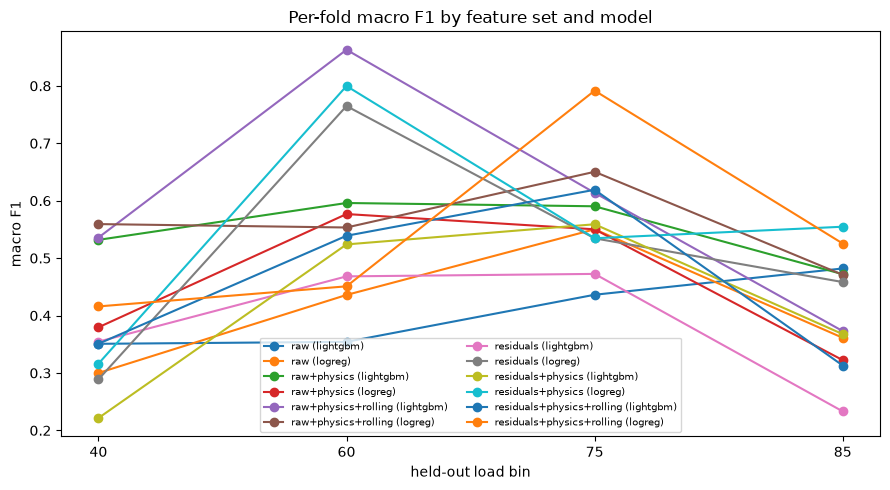

In [4]:
per_fold = results[results["fold"] != "pooled"]
fig, ax = plt.subplots(figsize=(9, 5))
for (feature_set, model), group in per_fold.groupby(["feature_set", "model"]):
    group = group.sort_values("fold")
    ax.plot(
        group["fold"].astype(str),
        group["macro_f1"],
        marker="o",
        label=f"{feature_set} ({model})",
    )
ax.set_xlabel("held-out load bin")
ax.set_ylabel("macro F1")
ax.set_title("Per-fold macro F1 by feature set and model")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(paths.FIGURES / "03_ablation.png", dpi=150)
plt.show()

## What this means for the next notebook

Numbers above are read from the executed run, not tuned to hit a target.
Notebook 03 part 2 prunes feature sets inside the training folds; part 3
reports the shop-test score, findings and the decision.